# 口座開設申し込みデータ EDA テンプレート

目的：口座開設の申し込み情報から、開設（承認）と謝絶の2クラスの傾向を分析する

--- 

## 分析の流れ

1. データ読込・基本確認
2. ターゲット変数の分布確認
3. 欠損値・データ品質チェック
4. 数値変数の分布分析
5. カテゴリ変数の分布分析
6. クラス別の比較分析
7. 相関分析

## 0. ライブラリのインポート

In [12]:
# Standard
#import warnings


# 3rd party
import japanize_matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# 表示設定
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

# グラフの設定
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

# クラスカラー
CLASS_COLORS = {"開設": "#4C72B0", "謝絶": "#DD8452"}
TARGET_COL = "label"
POS_LABEL = "開設"
NEG_LABEL = "謝絶"

## 1. データ読込・基本確認

In [4]:
# ダミーデータ
np.random.seed(42)
n = 2000
df = pd.DataFrame({
    TARGET_COL              : np.random.choice([POS_LABEL, NEG_LABEL], n, p=[0.65, 0.35]),
    'age'                   : np.random.normal(40, 12, n).clip(18, 80).astype(int),
    'annual_income'         : np.random.lognormal(6.5, 0.6, n).round(-3),
    'employment_years'      : np.random.exponential(5, n).clip(0, 40).round(1),
    'num_existing_accounts' : np.random.poisson(1.2, n),
    'credit_score'          : np.random.normal(620, 80, n).clip(300, 900).astype(int),
    'employment_type'       : np.random.choice(['正社員','契約社員','自営業','無職'], n, p=[0.55,0.2,0.15,0.1]),
    'residence_type'        : np.random.choice(['持家','賃貸','その他'], n, p=[0.45,0.45,0.1]),
    'has_other_bank'        : np.random.choice(['あり','なし'], n, p=[0.6,0.4]),
})
# 欠損値
df.loc[df.sample(frac=0.03).index, "annual_income"] = np.nan
df.loc[df.sample(frac=0.02).index, "credit_score"]  = np.nan

print(f"行数: {len(df):,} / 列数: {df.shape[1]}")

print(df.dtypes)
display(df.describe(include="all").T)

行数: 2,000 / 列数: 9
label                        str
age                        int64
annual_income            float64
employment_years         float64
num_existing_accounts      int64
credit_score             float64
employment_type              str
residence_type               str
has_other_bank               str
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
label,2000,2,開設,1301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2000.00,NaN,NaN,NaN,39.77,11.61,18.00,32.00,40.00,48.00,80.00
annual_income,1940.00,NaN,NaN,NaN,759.28,635.30,0.00,0.00,1000.00,1000.00,5000.00
employment_years,2000.00,NaN,NaN,NaN,4.68,4.65,0.00,1.40,3.30,6.30,34.10
num_existing_accounts,2000.00,NaN,NaN,NaN,1.18,1.09,0.00,0.00,1.00,2.00,7.00
credit_score,1960.00,NaN,NaN,NaN,618.22,78.23,349.00,567.00,616.00,671.00,890.00
employment_type,2000,4,正社員,1071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
residence_type,2000,3,賃貸,927,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_other_bank,2000,2,あり,1167,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. ターゲット変数の分布

,件数,割合(%)
label,,
開設,1301,65.00
謝絶,699,34.90


/Users/udai/miniforge3/envs/fraud-detection/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38283 (\N{CJK UNIFIED IDEOGRAPH-958B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/udai/miniforge3/envs/fraud-detection/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35373 (\N{CJK UNIFIED IDEOGRAPH-8A2D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/udai/miniforge3/envs/fraud-detection/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35613 (\N{CJK UNIFIED IDEOGRAPH-8B1D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/udai/miniforge3/envs/fraud-detection/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32118 (\N{CJK UNIFIED IDEOGRAPH-7D76}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/udai/miniforge3/envs/fraud-detection/lib/python3.14/site-pack

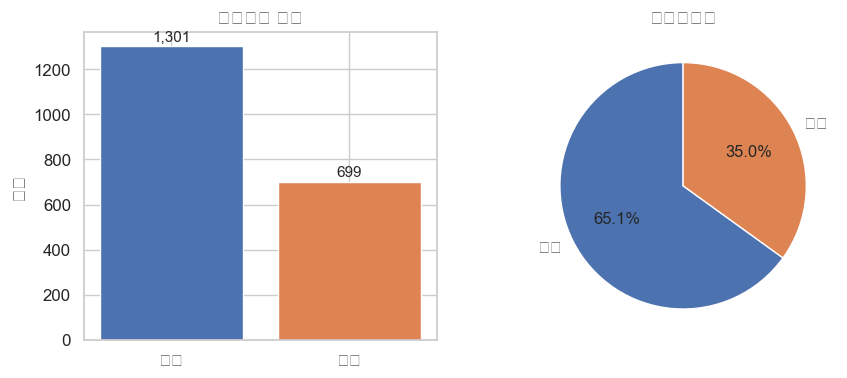

In [14]:
target_counts = df[TARGET_COL].value_counts()
target_ratio  = df[TARGET_COL].value_counts(normalize=True).mul(100).round(1)

summary = pd.DataFrame({"件数": target_counts, "割合(%)": target_ratio})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 棒グラフ
bars = axes[0].bar(target_counts.index, target_counts.values,
                   color=[CLASS_COLORS.get(k, '#999') for k in target_counts.index])
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('クラス別 件数', fontsize=13)
axes[0].set_ylabel('件数')

# 円グラフ
axes[1].pie(target_counts.values, labels=target_counts.index,
            colors=[CLASS_COLORS.get(k, '#999') for k in target_counts.index],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('クラス比率', fontsize=13)

#plt.tight_layout()
plt.show()

## 3. 欠損値・データ品質チェック

,欠損数,欠損率(%)
annual_income,60,3.00
credit_score,40,2.00


/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/3703148647.py:16: UserWarning: Glyph 27424 (\N{CJK UNIFIED IDEOGRAPH-6B20}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/3703148647.py:16: UserWarning: Glyph 25613 (\N{CJK UNIFIED IDEOGRAPH-640D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/3703148647.py:16: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/3703148647.py:16: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/3703148647.py:16: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) Arial.
  plt.tight_layout()
/Users/udai/miniforge3/envs/fraud-detection/lib/py

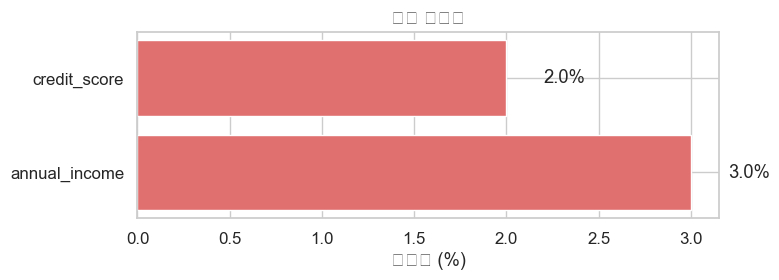

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'欠損数': missing, '欠損率(%)': missing_pct})
missing_df = missing_df[missing_df['欠損数'] > 0].sort_values('欠損率(%)', ascending=False)

if missing_df.empty:
    print('✅ 欠損値はありません')
else:
    display(missing_df)
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing_df)*0.5)))
    ax.barh(missing_df.index, missing_df['欠損率(%)'], color='#E07070')
    ax.set_xlabel('欠損率 (%)')
    ax.set_title('列別 欠損率')
    for i, v in enumerate(missing_df['欠損率(%)']):
        ax.text(v + 0.2, i, f'{v}%', va='center')
    plt.tight_layout()
    plt.show()

## 4. 数値変数の分布分析

数値列: ['age', 'annual_income', 'employment_years', 'num_existing_accounts', 'credit_score']


/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/889357756.py:21: UserWarning: Glyph 35613 (\N{CJK UNIFIED IDEOGRAPH-8B1D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/889357756.py:21: UserWarning: Glyph 32118 (\N{CJK UNIFIED IDEOGRAPH-7D76}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/889357756.py:21: UserWarning: Glyph 38283 (\N{CJK UNIFIED IDEOGRAPH-958B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/889357756.py:21: UserWarning: Glyph 35373 (\N{CJK UNIFIED IDEOGRAPH-8A2D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/889357756.py:21: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipyker

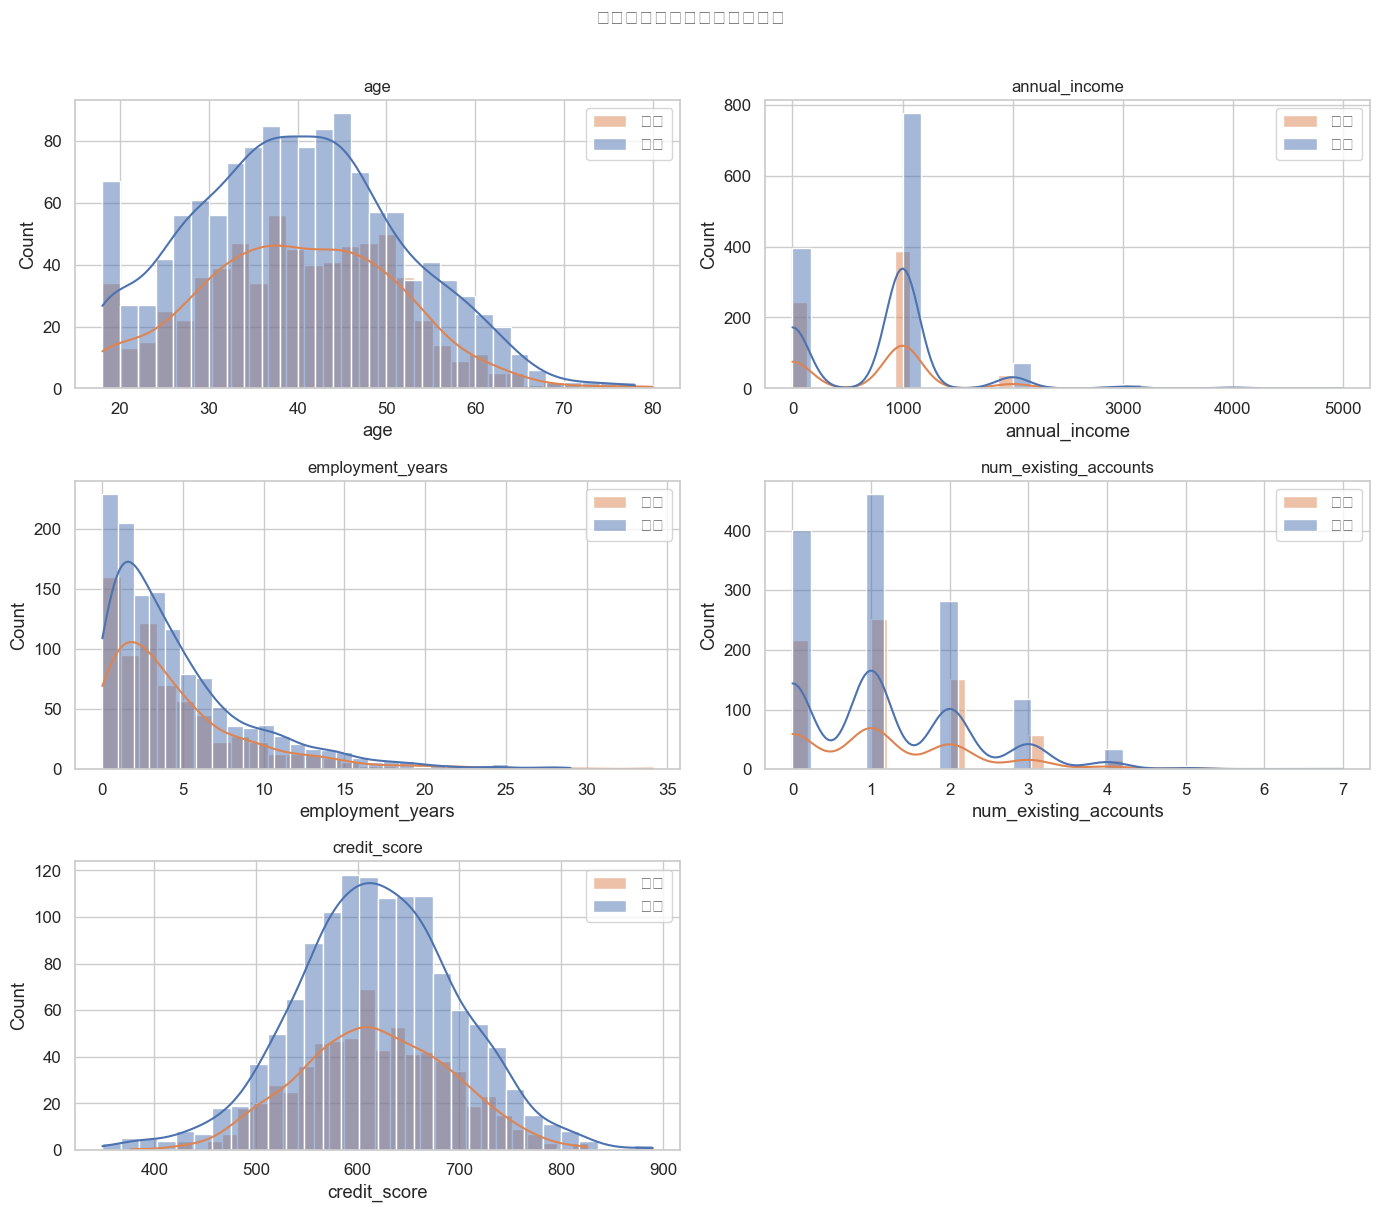

In [10]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'数値列: {num_cols}')

n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, grp in df.groupby(TARGET_COL):
        sns.histplot(grp[col].dropna(), ax=axes[i], kde=True,
                     color=CLASS_COLORS.get(label, '#999'),
                     label=label, alpha=0.5, bins=30)
    axes[i].set_title(col, fontsize=12)
    axes[i].legend()

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('数値変数の分布（クラス別）', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/304575221.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[i],
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/304575221.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[i],
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/304575221.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[i],
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r

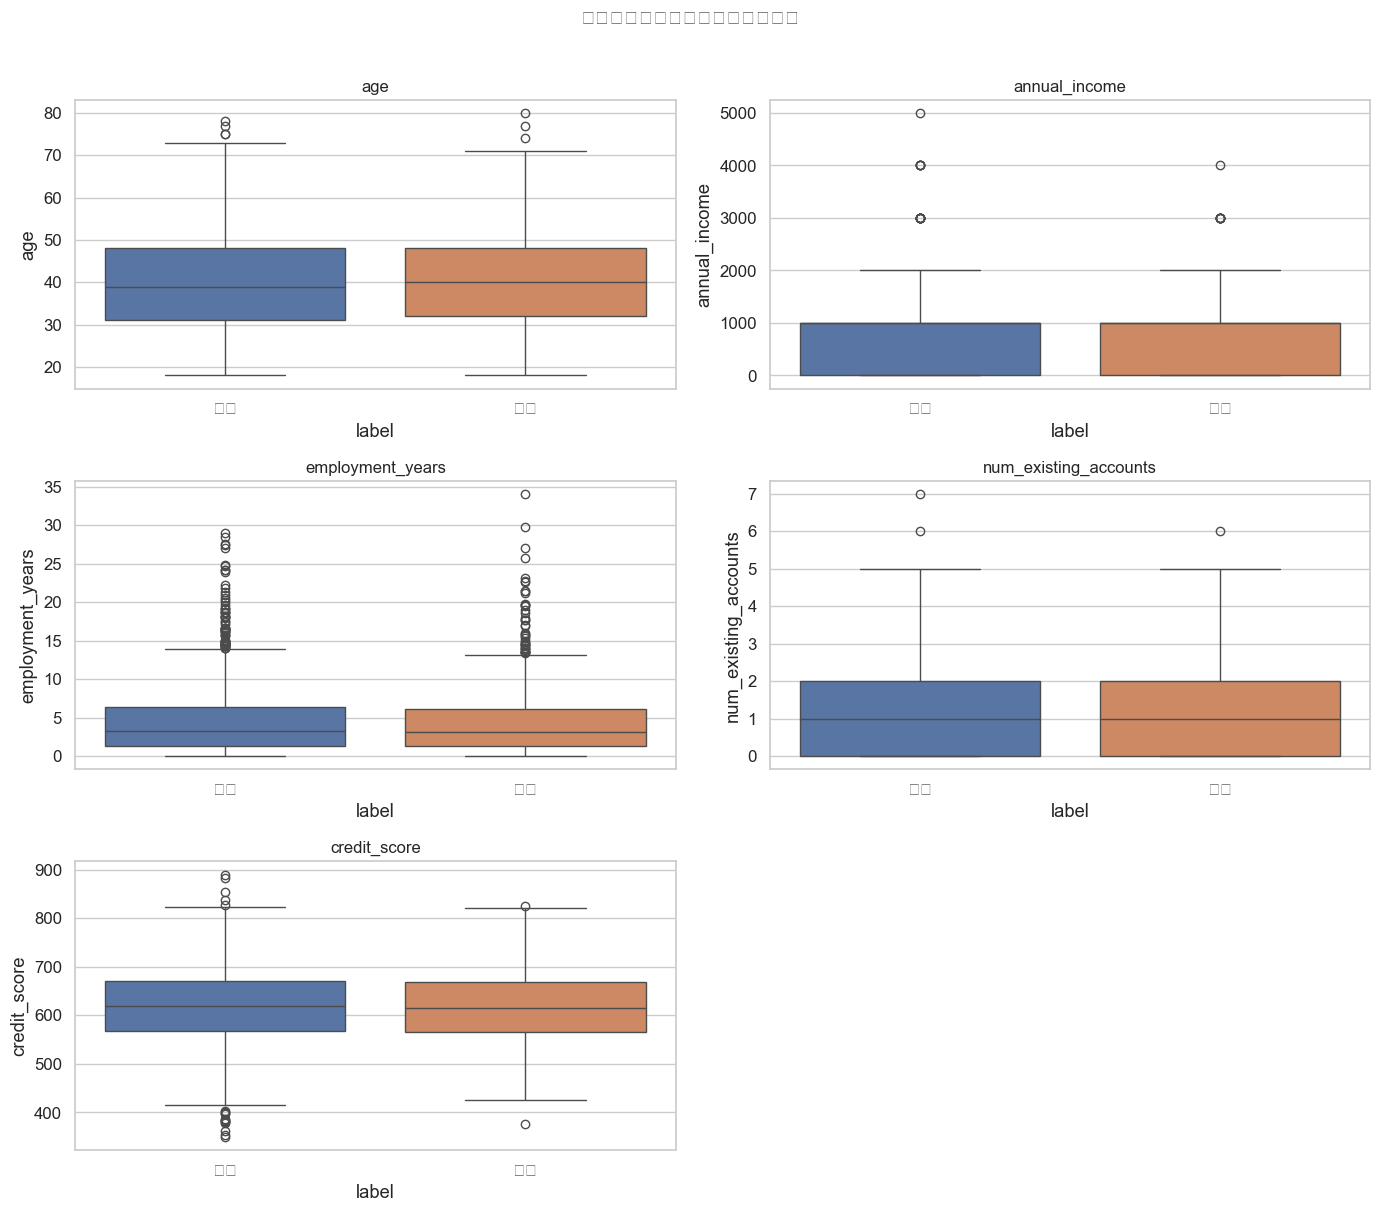

In [15]:
# ---- Box Plot で外れ値も確認 ----
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[i],
                palette=CLASS_COLORS, order=[POS_LABEL, NEG_LABEL])
    axes[i].set_title(col, fontsize=12)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('数値変数の箱ひげ図（クラス別）', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. カテゴリ変数の分布分析

/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [c for c in df.select_dtypes(include='object').columns if c != TARGET_COL]
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 22865 (\N{CJK UNIFIED IDEOGRAPH-5951}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 32004 (\N{CJK UNIFIED IDEOGRAPH-7D04}) missing from font(s) Arial.
  plt.

カテゴリ列: ['employment_type', 'residence_type', 'has_other_bank']


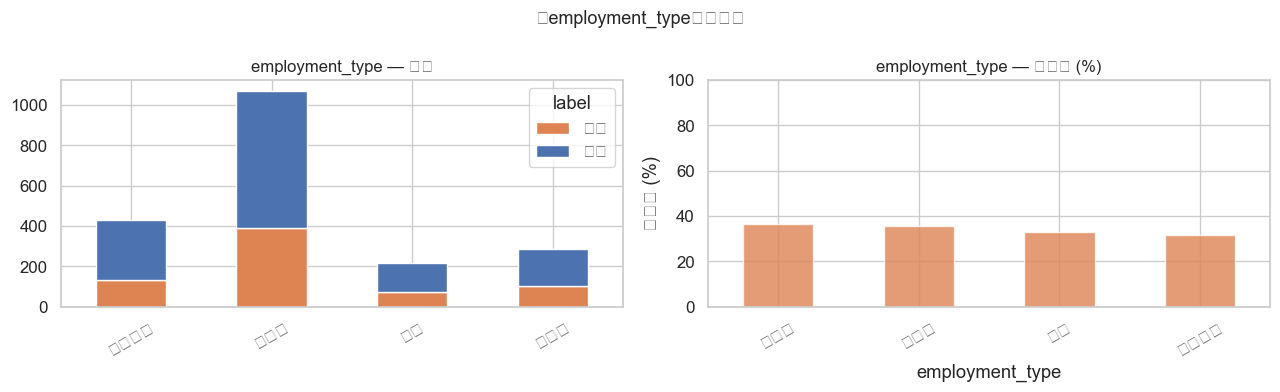

/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 12381 (\N{HIRAGANA LETTER SO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 20182 (\N{CJK UNIFIED IDEOGRAPH-4ED6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1

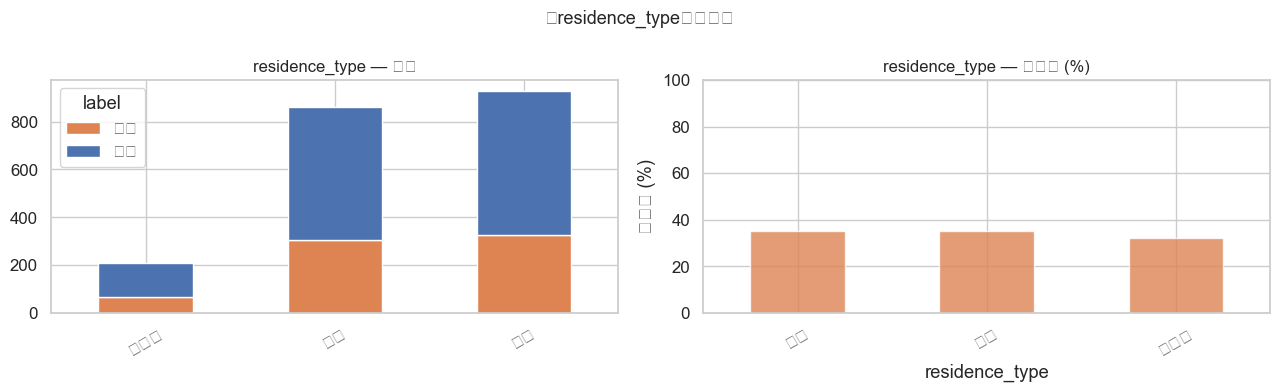

/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 12354 (\N{HIRAGANA LETTER A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 12375 (\N{HIRAGANA LETTER SI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/1037913577.py:27: 

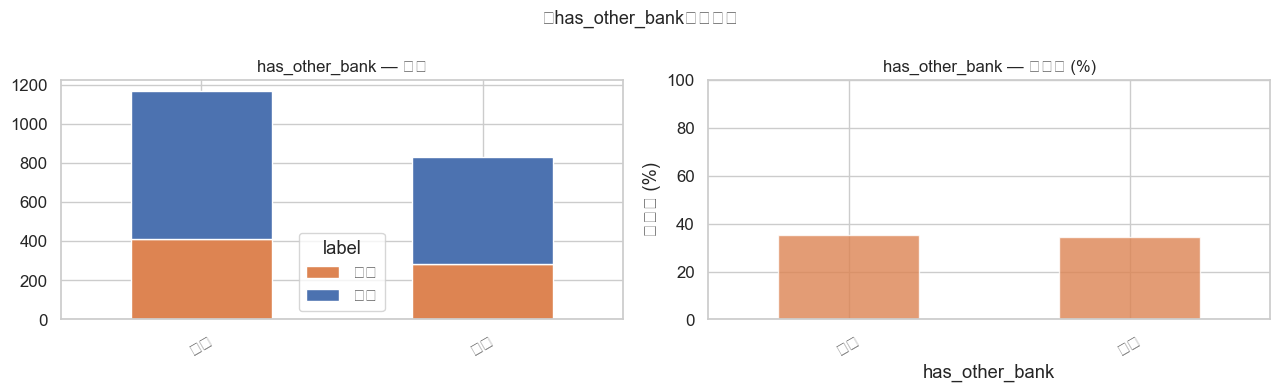

In [16]:
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != TARGET_COL]
print(f'カテゴリ列: {cat_cols}')

for col in cat_cols:
    ct = pd.crosstab(df[col], df[TARGET_COL], normalize='index') * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    
    # 件数の積み上げ棒グラフ
    ct_count = pd.crosstab(df[col], df[TARGET_COL])
    ct_count.plot(kind='bar', ax=axes[0], stacked=True,
                  color=[CLASS_COLORS.get(c, '#999') for c in ct_count.columns])
    axes[0].set_title(f'{col} — 件数', fontsize=12)
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=30)
    
    # 謝絶率の棒グラフ
    rejection_rate = ct.get(NEG_LABEL, pd.Series(dtype=float))
    rejection_rate.sort_values(ascending=False).plot(
        kind='bar', ax=axes[1], color='#DD8452', alpha=0.8)
    axes[1].set_title(f'{col} — 謝絶率 (%)', fontsize=12)
    axes[1].set_ylabel('謝絶率 (%)')
    axes[1].set_ylim(0, 100)
    axes[1].tick_params(axis='x', rotation=30)
    
    plt.suptitle(f'【{col}】の分布', fontsize=13)
    plt.tight_layout()
    plt.show()
    print()

## 6. クラス別 統計量の比較

In [22]:
stats

label                             謝絶      開設
age                   mean     39.98   39.66
                      median   40.00   39.00
                      std      11.16   11.84
annual_income         mean    727.94  776.19
                      median 1000.00 1000.00
                      std     633.70  635.77
employment_years      mean      4.62    4.72
                      median    3.10    3.30
                      std       4.70    4.63
num_existing_accounts mean      1.18    1.19
                      median    1.00    1.00
                      std       1.09    1.09
credit_score          mean    617.13  618.81
                      median  614.00  619.00
                      std      74.08   80.40

In [26]:
stats = df.groupby(TARGET_COL)[num_cols].agg(['mean', 'median', 'std']).T
#stats.columns = [f'{c[0]}{c[1]}' for c in stats.columns]

# 平均の差（絶対値）と差異率
if f'{POS_LABEL}_mean' in stats.columns and f'{NEG_LABEL}_mean' in stats.columns:
    stats['平均差(開設-謝絶)'] = stats[f'{POS_LABEL}_mean'] - stats[f'{NEG_LABEL}_mean']
    stats['差異率(%)'] = (stats['平均差(開設-謝絶)'] / stats[f'{POS_LABEL}_mean'].abs() * 100).round(1)

#display(stats.style.background_gradient(cmap='RdYlGn', subset=['差異率(%)']))
stats.style.background_gradient(cmap="RdYlGn")

## 7. 相関分析

/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/3525846262.py:9: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/3525846262.py:9: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/3525846262.py:9: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/3525846262.py:9: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/3525846262.py:9: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipyker

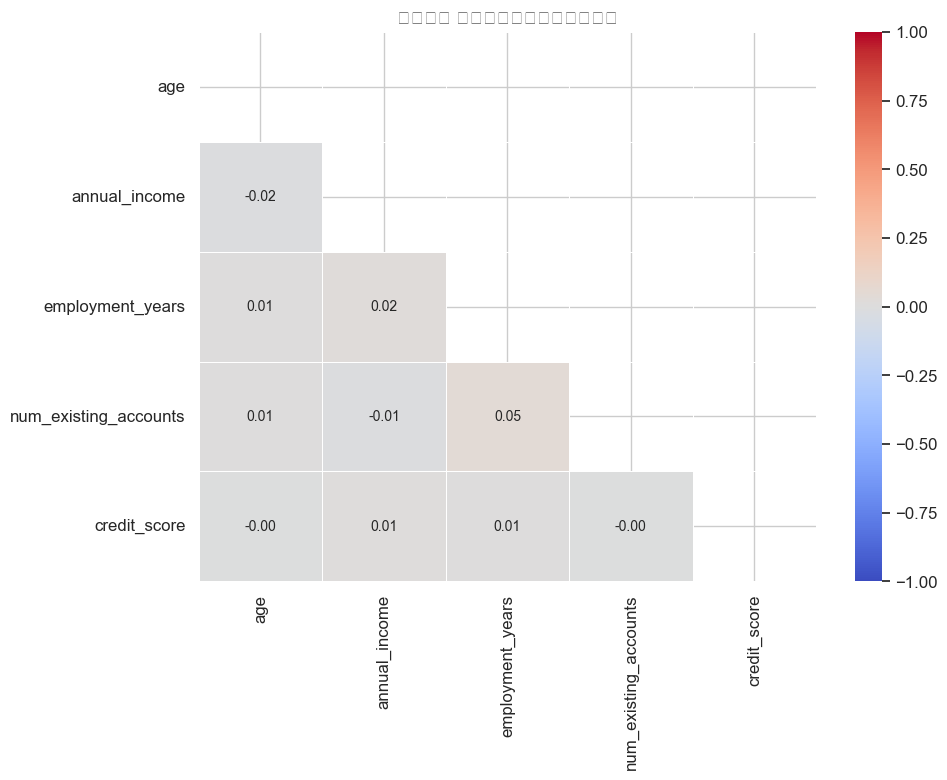

In [27]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 10})
ax.set_title('数値変数 相関マトリクス（下三角）', fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/402652592.py:11: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/402652592.py:11: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/402652592.py:11: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/402652592.py:11: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_74912/402652592.py:11: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipyker

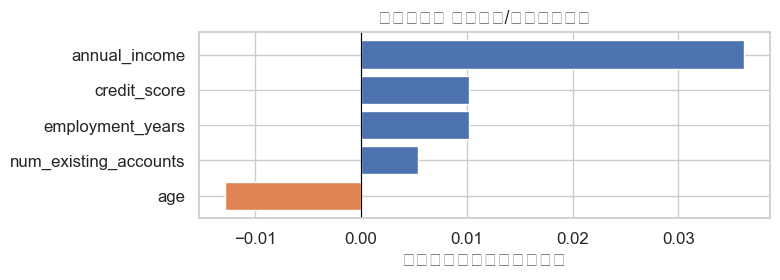

In [28]:
# ---- ラベルを数値に変換して各変数とターゲットの相関を確認 ----
df['_target_num'] = (df[TARGET_COL] == POS_LABEL).astype(int)
target_corr = df[num_cols + ['_target_num']].corr()['_target_num'].drop('_target_num').sort_values()

fig, ax = plt.subplots(figsize=(8, max(3, len(target_corr)*0.5)))
colors = ['#DD8452' if v < 0 else '#4C72B0' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('相関係数（対ターゲット）')
ax.set_title('各数値変数 と「開設/謝絶」の相関', fontsize=13)
plt.tight_layout()
plt.show()
df.drop(columns=['_target_num'], inplace=True)

## 8. Pair Plot (変数間の散布図マトリクス)

/Users/udai/miniforge3/envs/fraud-detection/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 38283 (\N{CJK UNIFIED IDEOGRAPH-958B}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/udai/miniforge3/envs/fraud-detection/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 35373 (\N{CJK UNIFIED IDEOGRAPH-8A2D}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/udai/miniforge3/envs/fraud-detection/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 35613 (\N{CJK UNIFIED IDEOGRAPH-8B1D}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/udai/miniforge3/envs/fraud-detection/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 32118 (\N{CJK UNIFIED IDEOGRAPH-7D76}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/udai/miniforge3/envs/fraud-detection/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  fig.can

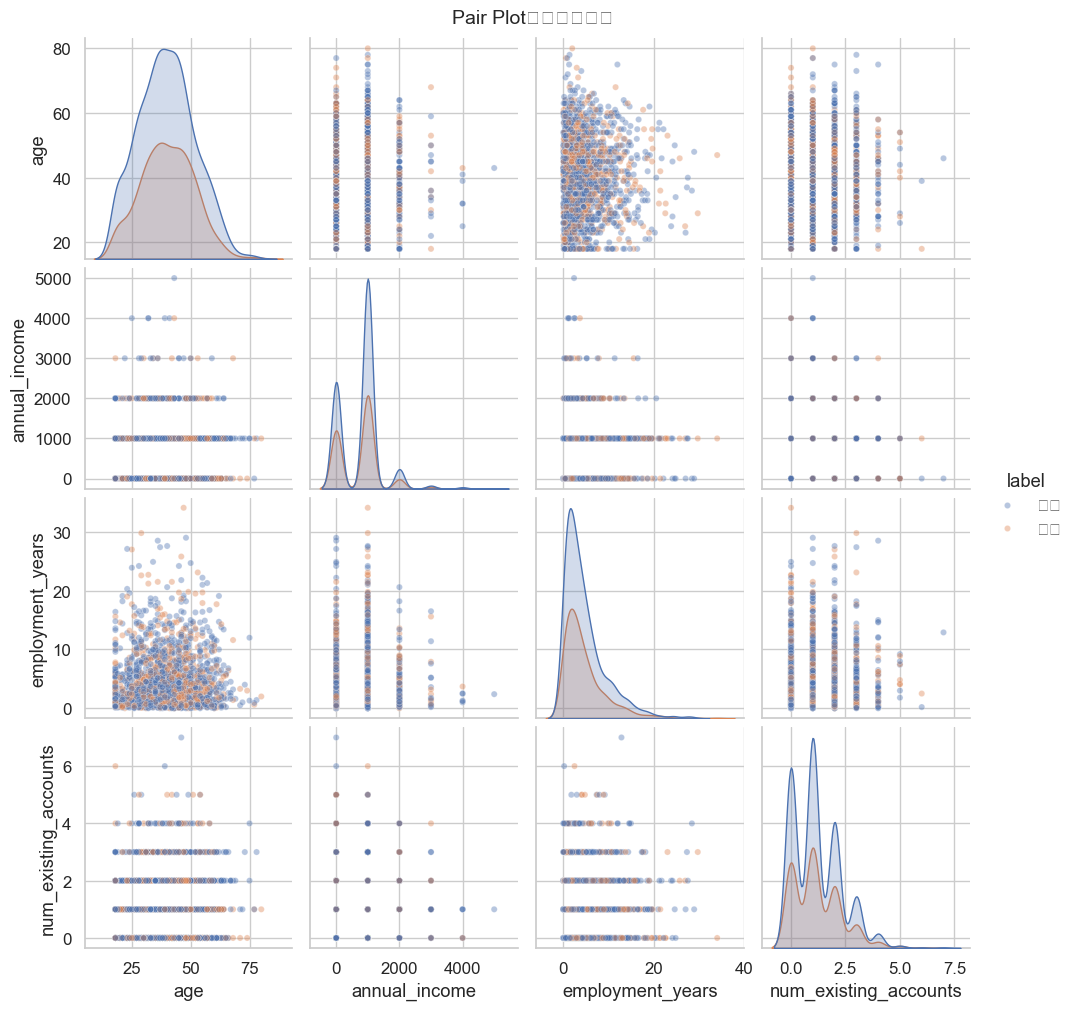

In [29]:
# ★ 確認したい列を選んで実行（列が多すぎると重くなります）
pair_cols = num_cols[:4]  # 最初の4列を使用

g = sns.pairplot(df[pair_cols + [TARGET_COL]].dropna(),
                 hue=TARGET_COL,
                 palette=CLASS_COLORS,
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kind='kde')
g.fig.suptitle('Pair Plot（クラス別）', y=1.01, fontsize=14)
plt.show()